# Structure of Spheroid Microscopy data

In this section, we will dicuss the structure of the spheroid microscopy images. This is managed in the `SpheroidPy.spheroid` modul. It follows a hierarchical structure, starting from individual (multichannel) images (`SpheroidImage`), from which instances from multiple timepoints can be combined in a timeseries (`SpheroidSeries`), from which then in turn multiple replicates can be combined in a collection (`SpheroidCollection`) for statistical analysis.

In [2]:
from SpheroidPy.utils.config import Config, AISegmentationType
Config.ai_segmentation = AISegmentationType.HRNET  # or AISegmentationType.DETECTRON

## __SpheroidImage:__  Individual (multichannel) Microscope Images

<img src="../docs/source/_images/example_SpheroidImage.png" width="400em" align="right" style="margin-left: 20px; margin-bottom: 20px; margin-top: -20px;" />

The `SpheroidImage` class is the most basic building block of SpheroidPy. It manages the microscopy images of different channels for one measurement of a spheroid. 

After loading the images, they can be segmented using different channels and methods (thresholding or deep learning).

In addition, mathematical calculations that only concern the Image are implemented in this class. For example, different quatifications using fluorescence intensities, radial profiles and even diffusion distributions using differential equations can be calculated using this class.


### __Creating a `SpheroidImage`:__
We start by importing the class

In [3]:
from SpheroidPy.spheroid import SpheroidImage

Information on what the class does and what parameters we need as input can be seen by typing

In [5]:
SpheroidImage?

Init signature: SpheroidImage(brightfield: pathlib.Path | str = None, **kwargs)
Docstring:     
A class for analyzing and processing images of spheroids.

Attributes
----------
image_path_dict : dict
    Mapping of channel name to image path.
image_size : tuple
    Height and width of the image in µm (from any available channel).
hdf5_path : str or Path, optional
    Path to associated HDF5 file (if provided).
hdf5_key : str, optional
    Key for accessing data in HDF5 file (if provided).
analysis_results : dict
    Stores computed analysis results.
contour : ndarray or None
    Contour of the spheroid (if detected).
contour_touches_border : bool or None
    Whether the spheroid contour touches the image border.

Examples
--------
>>> # With brightfield (traditional usage)
>>> img = SpheroidImage(
...     brightfield="path/to/brightfield.tif",
...     fluorescence_green="path/to/green.tif",
...     image_size=(1080, 1920)
... )
>>> 
>>> # Without brightfield (at least one channel requi

So now we can create a Spheroid based on a brightfield/phase contrast image and optionally fluorescence images

In [10]:
# specify the paths of your Images
path_pc='example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_C4_1_2025y05m20d_18h00m.tif'          #PhaseContrast
path_green='example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_C4_1_2025y05m20d_18h00m.tif'  #green Fluorescence
path_red='example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_C4_1_2025y05m20d_18h00m.tif'        #red Fluorescence

# create a SpheroidImage
my_spheroid = SpheroidImage(brightfield = path_pc, fluorescence_green = path_green, fluorescence_red = path_red, #paths
                           image_size = (1700,1270)) # size of image in x- and y-direction [µm]

We can test the images to see if everything worked and the Spheroid has been created successfully

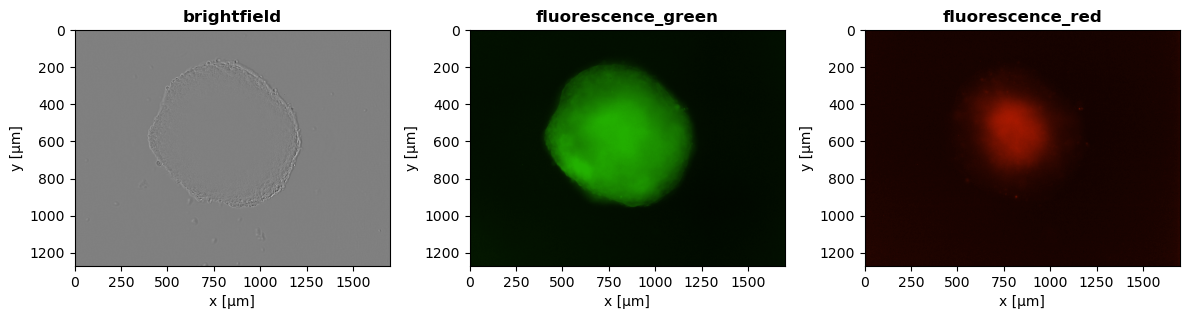

In [13]:
my_spheroid.show()

### __Segmentation:__
Now that we are familiar with the creation of SpheroidImages, we can start extracting some valueable information out of it. As for that we almost always need to know the exact boundary of the spheroid first, we start by segmenting the spheroid. For that two methods have been implemented:

__1. Thresholding:__  applies either Otsu- or Yen-based global thresholding, optionally scaled by a user-defined multiplier [best for fluorescence or brightfield with strong contrasts]

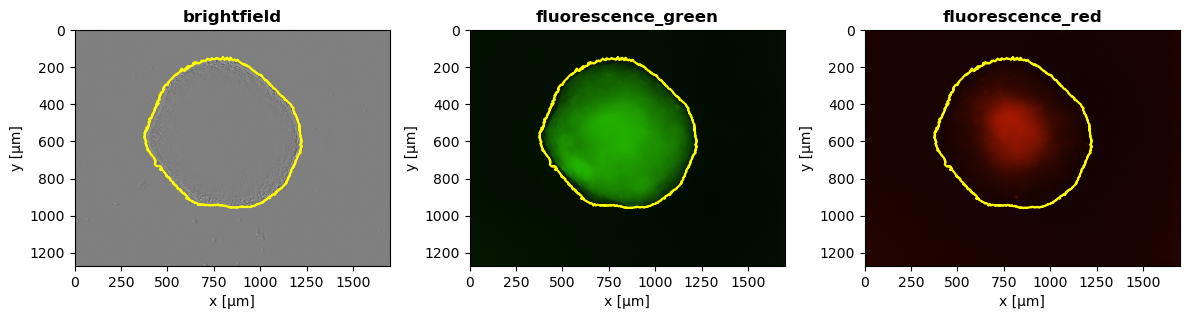

In [16]:
my_spheroid.segmentation_thresholding(channel='fluorescence_green', thres=1.)
my_spheroid.show()

<br>

__2. Deep learning:__   supports two interchangeable models (a Mask R-CNN based on Detectron2 and a High-Resolution Network (HRNet)) [best for phase-contrast]

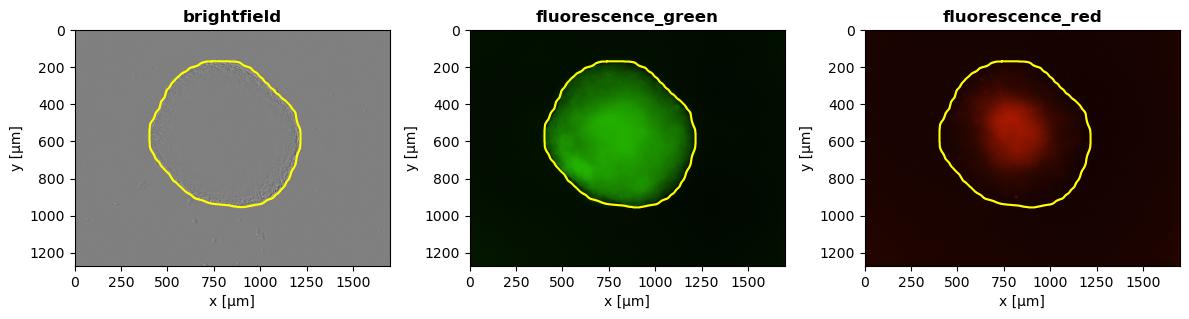

In [19]:
my_spheroid.segmentation_detectron('brightfield', 0.8)
my_spheroid.show()

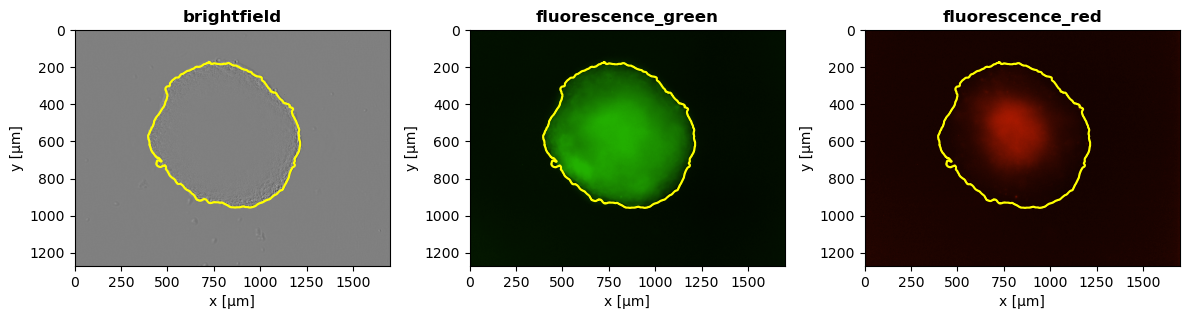

In [21]:
my_spheroid.segmentation_hrnet('brightfield', 0.8)
my_spheroid.show()

The main `segmentation()` orchestrator function allows the execution of a user-specified combination of thresholding and/or deep-learning-based approaches on specified channels sequentially and returns the first valid contour.

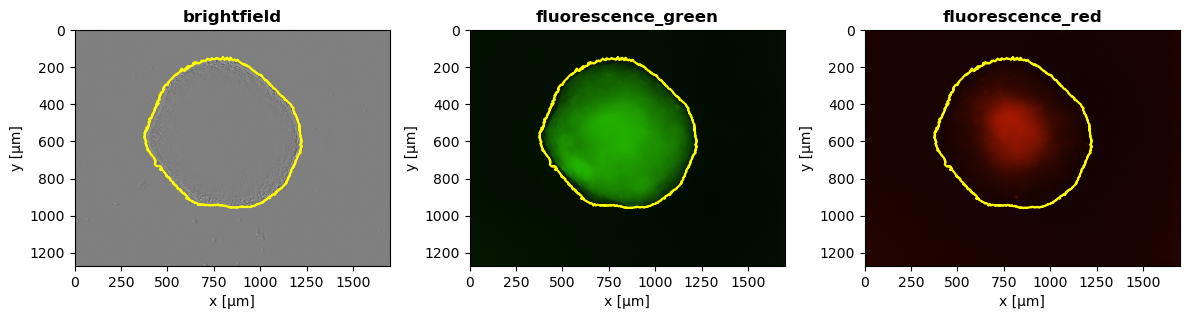

In [28]:
my_spheroid.segmentation([('thresholding', 'fluorescence_green'), ('ai', 'brightfield')], threshold=1., confidence=0.8)
my_spheroid.show()

Furthermore, the method also looks for possible pertubations, i.e. if parts of the spheroid are out of frame

In [30]:
my_spheroid.contour_touches_border

False

An additional interactive manual segmentation method is available as a fallback method, allowing users to delineate contours directly within a graphical interface.

In [ ]:
my_spheroid.segmentation_manual('brightfield')

<br>

__Simple Metrics:__
After segmentation simple metrics - such as effective radius ($\sqrt{\frac{area}{\pi}}$), area and fluorescence intensity (mean and cumulative) - can be extracted:

In [32]:
my_spheroid.radius, my_spheroid.area, my_spheroid.metric_fluorescence('green')

(401.5850833509501, 506646.4667606101, (24859302, 72.9373267103051))

<br>

### __Advanced Usage:__
After performing the segmentation, it is also possible to get more advanced information from the provided images. 


__Radial Profiles:__
To quantify spatial fluorescence distributions, SpheroidPy computes boundary-normalized radial intensity profiles by shell averaging.

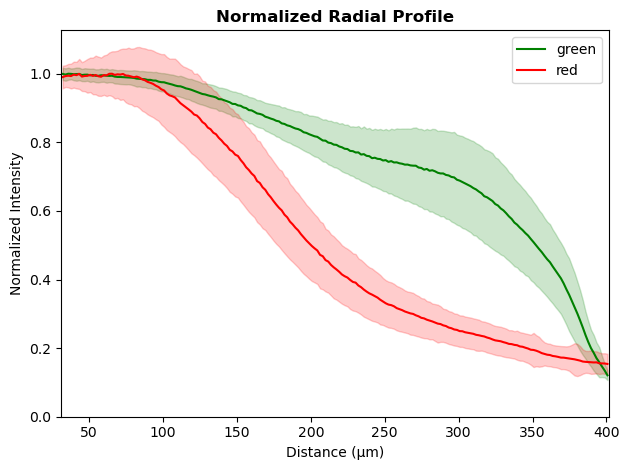

In [34]:
rad_prof_dict = my_spheroid.radial_profile(channels=['green', 'red'], plot=True, nbins=200, smoothing=0, absolute_radius=True)

<br><br><br><br>

## __SpheroidSeries:__ Timeseries of multiple SpheroidImages
<img src="../docs/source/_images/example_SpheroidSeries.png" width="400em" align="right" style="margin-left: 20px; margin-bottom: 30px; margin-top: -30px;" />

In Experiments it often is necessary to observe a spheroid over a longer period for different timepoints. 
To simplify the data handling of such processes, multiple `SpheroidImage` instances of the same spheroid at different timepoints can be combined into one `SpheroidSeries`. 
This allows for the management of time-lapse microscopy data and investigation of the evolution of the spheroid over time.

#### __Creating `SpheroidSeries`:__
Similarly, first an instance of the `SpheroidSeries` class has to initiated. Afterwards multiple `SpheroidImage` instances can be added.
In our case we take a look at the previous Spheroid from Well C5 for which we have images taken after every 48h.


In [36]:
from SpheroidPy.spheroid import SpheroidSeries, SpheroidImage    # import of the class
from datetime import datetime                     # module for timepoints

spheroid_series = SpheroidSeries('HCT116 Timeseries')

In [38]:
# creating and adding SpheroidImages for every 48h
for day in range(10,22,2):
    # timepoint of image
    date_time = datetime.strptime(f'2025y05m{day}d_18h00m', '%Yy%mm%dd_%Hh%Mm')
    # path of the image channels
    path_pc=f'example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_C5_1_2025y05m{day}d_18h00m.tif'          #PhaseContrast
    path_green=f'example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_C5_1_2025y05m{day}d_18h00m.tif'  #green Fluorescence
    path_red=f'example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_C5_1_2025y05m{day}d_18h00m.tif'        #red Fluorescence

    # create a SpheroidImage
    my_spheroid = SpheroidImage(brightfield = path_pc, fluorescence_green = path_green, fluorescence_red = path_red, image_size = (1700,1270))
    # add to SpheroidSeries
    spheroid_series.add_spheroid_image(my_spheroid, date_time)

We can now visualise our Series using an interactive build-in method:

In [41]:
spheroid_series.show()

#### __Basic Usage:__
In a next step, the images have to be segmented first in order to identify the evolution of the spheroids over time. This can be done in a similar way is previously

In [43]:
from SpheroidPy.utils.config import Config, AISegmentationType
Config.ai_segmentation = AISegmentationType.HRNET

spheroid_series.segmentation(methods=[('ai', 'brightfield'),('thresholding', 'fluorescence_green')], threshold=1.3, confidence=.7, border_margin=7)

Segmentation finished: 6/6 images segmented successfully.


Afterwards the segmentation performance can be validated again using the interactive `show()` method.

Furthermore, the `metric()` function allows for a convenient extraction of quantitative measures. There are currently the following metrics available
- based on contour: 'radius', 'area'
- based on fluorescence intensity: 'fluorescence_(color)_ cumulative' or 'fluorescence_(color)_mean'

For further processing outside of python the pandas dataframe can be stored, i.e. as a Excel file ( `df.to_excel('test123.xlsx')` )

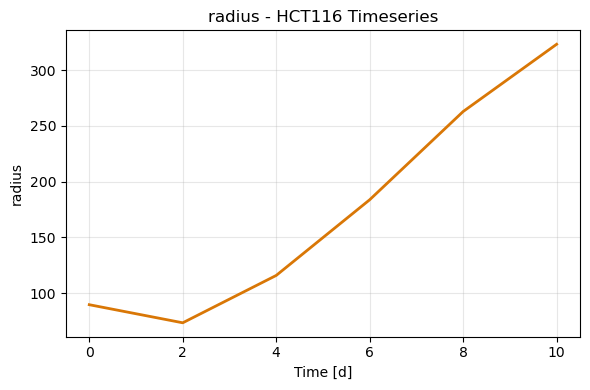

,HCT116 Timeseries
0.0,89.592996
48.0,73.354348
96.0,115.861579
144.0,183.782466
192.0,262.973558
240.0,323.334360


In [109]:
df, ax = spheroid_series.metric('radius', plot=True)
df

If it is desired to restrict the investigation to certain time peroids during the experiment, this can be done using the `TimePeroid` class which manages ... and is embedded into the `SpheroidSeries` class via the following method

In [132]:
spheroid_series.time_period('Proliferation', start_time='2025-05-14 18:00:00', end_time='2025-05-24 18:00:00')

TimePeriod(name='Proliferation', start=2025-05-14 18:00:00, end=2025-05-24 18:00:00)

##### __Exporting Videos:__
The resulting figures can be saved locally. In addition, videos of both inidivual channels as well as overlay of several ... can be exported for visualisation purposes.

In [141]:
spheroid_series.export_video(video_name='HCT116_video.mp4', channel='brightfield', overlay_channels=['fluorescence_green'], contour=True, fps=2, time=True)#?

Processing Images:   0%|          | 0/6 [00:00<?, ?it/s]OpenCV: FFMPEG: tag 0x44495658/'XVID' is not supported with codec id 12 and format 'mp4 / MP4 (MPEG-4 Part 14)'
OpenCV: FFMPEG: fallback to use tag 0x7634706d/'mp4v'
Processing Images: 100%|██████████| 6/6 [00:00<00:00, 63.02it/s]

Video abgeschlossen. Datei wurde gespeichert unter: HCT116_video.mp4


<br><br><br><br>

## __SpheroidCollection:__ Managing Sets of multiple SpheroidSeries
<img src="../docs/source/_images/example_SpheroidCollection.png" width="500em" align="right" style="margin-left: 50px; margin-bottom: 25px; margin-top: 10px;" />

If there are available multiple replicates, i.e. in a technical or biological sense, it often proves useful being able to combine them into one instance, so that (statistical) analyses can be streamlined and measures easily compared for different `SpheroidSeries`. Therefore, it is possible to merge multiple `SpheroidSeries` into one instance of the `SpheroidCollection`.

#### __Creating `SpheroidCollection`:__
In the following example we show this for three technical replicate Wells B5, C5, D5, which have been seeded under the same conditions and have been recorded at the same timepoints. First we have to  create `SpheroidSeries` for the three wells - similarly as shown before - and save them in an empty list:

In [47]:
from SpheroidPy.spheroid import SpheroidCollection, SpheroidSeries, SpheroidImage   # import the class
from datetime import datetime

spheroidseries_list = []
for well_name in ['B4', 'C4']:
    spheroid_series = SpheroidSeries(name=f'Well {well_name}')
    
    for day in range(10,22,2):
        date_time = datetime.strptime(f'2025y05m{day}d_18h00m', '%Yy%mm%dd_%Hh%Mm')
        path_pc=f'example_data/PhaseContrast/HCT116_SpheroidProliferation_PhaseContrast_raw_{well_name}_1_2025y05m{day}d_18h00m.tif'          #PhaseContrast
        path_green=f'example_data/FluorescenceGreen/HCT116_SpheroidProliferation_fluorescence_green_{well_name}_1_2025y05m{day}d_18h00m.tif'  #green Fluorescence
        path_red=f'example_data/FluorescenceRed/HCT116_SpheroidProliferation_fluorescence_red_{well_name}_1_2025y05m{day}d_18h00m.tif'        #red Fluorescence

        # create a SpheroidImage and add to SpheroidSeries
        my_spheroid = SpheroidImage(brightfield = path_pc, 
                                    fluorescence_green = path_green, 
                                    fluorescence_red = path_red, 
                                    image_size = (1700,1270))
        spheroid_series.add_spheroid_image(my_spheroid, date_time)
        
    spheroidseries_list.append(spheroid_series) # add to our list
    
# create SpheroidCollection based on the list of SpheroidSeries objects
spheroid_collection = SpheroidCollection(name='HCT116_800_cells', spheroid_list=spheroidseries_list)


The `SpheroidCollection` can again be visualised using the `show()` method

In [50]:
spheroid_collection.show()

#### __Basic Usage:__
Similarly segmentation can be performed. For increased performanced, multiprocessing is used.

In [53]:
spheroid_collection.segmentation(methods=[('thresholding', 'fluorescence_green'),('ai', 'brightfield')])

Collection 'HCT116_800_cells': 100%|██████████| 2/2 [00:09<00:00,  4.72s/it]


Segmentation complete for collection 'HCT116_800_cells':
Successfully segmented 12/12 images across 2 series


(12, 12)

As the `SpheroidCollection` manages multiple `SpheroidSeries`it is now also possible to calculate statistics over the elements.

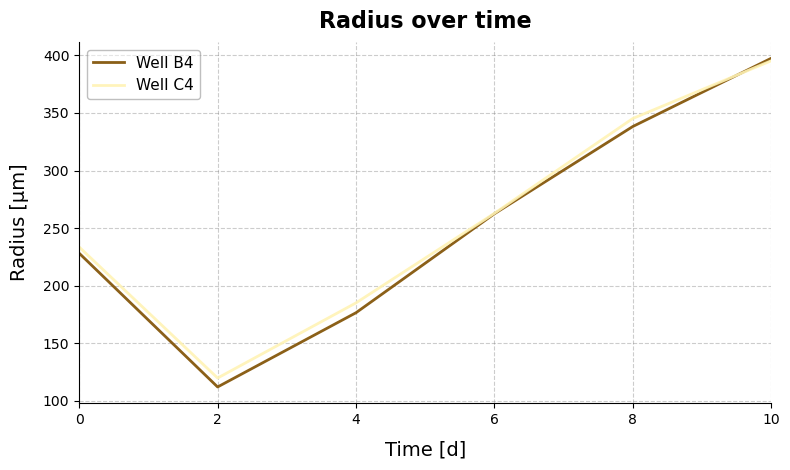

,Well B4,Well C4
0.0,228.057875,233.465613
48.0,111.903652,119.643074
96.0,176.406546,184.955927
144.0,262.398886,262.784850
192.0,338.214389,345.168875
240.0,397.488918,395.305155


In [54]:
df_single, ax = spheroid_collection.metric('radius', plot=True)
df_single

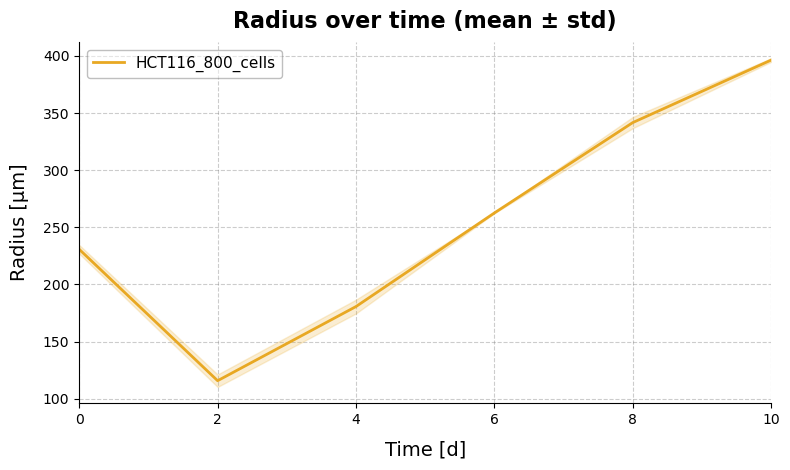

HCT116_800_cells          
                  mean       std
0.0         230.761744  3.823848
48.0        115.773363  5.472598
96.0        180.681236  6.045326
144.0       262.591868  0.272918
192.0       341.691632  4.917564
240.0       396.397036  1.544154

In [55]:
df_mean, ax = spheroid_collection.metric('radius', plot=True, mean=True)
df_mean